# Notebook 10 — Minh họa thông tin chi tiết Node và Cạnh

Notebook này minh họa cách kiểm tra các phần tử cụ thể trong đồ thị không đồng nhất của chúng ta. Chúng ta sẽ xem xét các node User và Item riêng lẻ, khám phá các khu vực lân cận của chúng (edges), và trực quan hóa một đồ thị con (subgraph) xung quanh một node cụ thể.

In [1]:
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import k_hop_subgraph, to_networkx
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 8)

In [2]:
PROCESSED_DIR = Path("../data/processed/")
data_path = PROCESSED_DIR / "hetero_data.pt"

data = torch.load(data_path, weights_only=False)
print("Dữ liệu đồ thị:\n", data)

Dữ liệu đồ thị:
 HeteroData(
  user={ x=[1642, 384] },
  item={ x=[21639, 384] },
  (user, reviews, item)={ edge_index=[2, 10751] },
  (item, also_bought, item)={ edge_index=[2, 7253] }
)


## 1. Kiểm tra thông tin một Node User
Chúng ta chọn một node User cụ thể (ví dụ: User 0) và xem xét các đặc trưng (features) cũng như các item mà họ đã đánh giá (review).

In [3]:
target_user = 0

# 1. Đặc trưng của User
user_features = data['user'].x[target_user]
print(f"--- USER {target_user} ---")
print(f"Kích thước Vector Đặc trưng: {user_features.shape}")
print(f"5 giá trị đặc trưng đầu tiên: {user_features[:5].numpy()}")

# 2. Các cạnh của User (Reviews)
reviews_edges = data['user', 'reviews', 'item'].edge_index
# Tìm các index mà source node là user mục tiêu
user_reviews_mask = (reviews_edges[0] == target_user)
reviewed_items = reviews_edges[1][user_reviews_mask]

print(f"\nUser {target_user} đã đánh giá {len(reviewed_items)} items.")
if len(reviewed_items) > 0:
    print(f"ID các Item đã đánh giá: {reviewed_items.numpy()}")

--- USER 0 ---
Kích thước Vector Đặc trưng: torch.Size([384])
5 giá trị đặc trưng đầu tiên: [-0.0639701   0.03117063  0.016055   -0.01101563  0.05157156]

User 0 đã đánh giá 8 items.
ID các Item đã đánh giá: [ 8514 10972 11223 11393 12839 14388 14788 17442]


## 2. Kiểm tra thông tin một Node Item & Chi tiết Cạnh
Chúng ta chọn một node Item cụ thể (ví dụ: Item 211 vì nó có nhiều liên kết) và kiểm tra cả các cạnh 'reviews' (được đánh giá bởi user nào) và các cạnh 'also_bought' (cùng được mua với các item nào khác).

In [4]:
target_item = 211

# 1. Đặc trưng của Item
item_features = data['item'].x[target_item]
print(f"--- ITEM {target_item} ---")
print(f"Kích thước Vector Đặc trưng: {item_features.shape}")

# 2. Các lượt Reviews nhận được
item_reviews_mask = (reviews_edges[1] == target_item)
reviewing_users = reviews_edges[0][item_reviews_mask]
print(f"\nItem {target_item} đã được đánh giá bởi {len(reviewing_users)} users.")
if len(reviewing_users) > 0:
    print(f"ID các User đã đánh giá: {reviewing_users.numpy()}")

# 3. Các cạnh Also Bought (cả đi và đến)
also_bought_edges = data['item', 'also_bought', 'item'].edge_index

out_bought_mask = (also_bought_edges[0] == target_item)
bought_items = also_bought_edges[1][out_bought_mask]
print(f"\nItem {target_item} được mua cùng với {len(bought_items)} items khác.")
if len(bought_items) > 0:
    print(f"ID các Item được mua cùng: {bought_items.numpy()}")

--- ITEM 211 ---
Kích thước Vector Đặc trưng: torch.Size([384])

Item 211 đã được đánh giá bởi 31 users.
ID các User đã đánh giá: [1304  109  909  964 1469  949 1189   32  206  615  233 1075 1403 1244
 1475 1176  858  766 1026  426  246  985 1362  967  629  160 1388  310
 1029 1513  596]

Item 211 được mua cùng với 3 items khác.
ID các Item được mua cùng: [20636 17890 20303]


## 3. Trực quan hóa Đồ thị con (Subgraph)
Để thực sự hiểu rõ cấu trúc liên kết cục bộ, hãy trích xuất một đồ thị con 1-hop xung quanh node Item và trực quan hóa nó. Chúng ta sẽ chuyển đồ thị không đồng nhất thành đồ thị đồng nhất chỉ để vẽ, đồng thời giữ lại thông tin loại node để tô màu cho phù hợp.

In [5]:
# Chuyển đổi thành đồ thị đồng nhất để dễ dàng trích xuất đồ thị con
homo_data = data.to_homogeneous()
print("Dữ liệu đồng nhất:\n", homo_data)

# Chúng ta cần ánh xạ item mục tiêu sang ID của nó trong đồ thị đồng nhất.
# Trong to_homogeneous() của PyG, các loại node được nối tiếp theo thứ tự: users, rồi items.
# Do đó, target_item_homo_id = num_users + target_item
num_users = data['user'].num_nodes
target_item_homo_id = num_users + target_item

# Trích xuất đồ thị con 1-hop xung quanh item mục tiêu
node_idx, edge_index_sub, mapping, edge_mask = k_hop_subgraph(
    node_idx=target_item_homo_id,
    num_hops=1,
    edge_index=homo_data.edge_index,
    relabel_nodes=True
)

print(f"\nĐồ thị con được trích xuất: {len(node_idx)} nodes và {edge_index_sub.shape[1]} edges.")

Dữ liệu đồng nhất:
 Data(edge_index=[2, 18004], x=[23281, 384], node_type=[23281], edge_type=[18004])

Đồ thị con được trích xuất: 32 nodes và 31 edges.


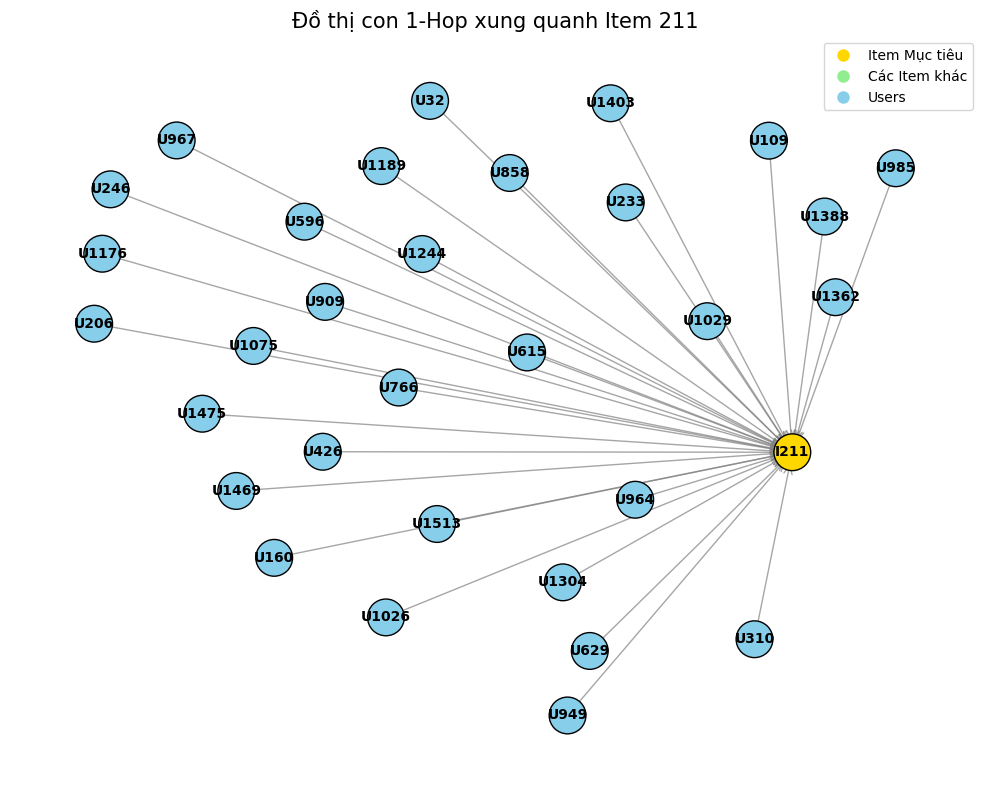

In [6]:
# Tạo đồ thị NetworkX từ đồ thị con
import torch_geometric
subgraph_data = torch_geometric.data.Data(edge_index=edge_index_sub, num_nodes=len(node_idx))
G_sub = to_networkx(subgraph_data, to_undirected=False)

# Chuẩn bị màu sắc dựa trên loại node
# Nodes < num_users là Users, ngược lại là Items
node_colors = []
labels = {}
for i, orig_idx in enumerate(node_idx.numpy()):
    if orig_idx < num_users:
        node_colors.append('skyblue') # User
        labels[i] = f"U{orig_idx}"
    else:
        item_idx = orig_idx - num_users
        if item_idx == target_item:
            node_colors.append('gold') # Target Item
        else:
            node_colors.append('lightgreen') # Other Item
        labels[i] = f"I{item_idx}"

# Vẽ đồ thị
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_sub, seed=42)

nx.draw_networkx_nodes(G_sub, pos, node_color=node_colors, node_size=700, edgecolors='black')
nx.draw_networkx_edges(G_sub, pos, arrowstyle='->', arrowsize=15, edge_color='gray', alpha=0.7)
nx.draw_networkx_labels(G_sub, pos, labels, font_size=10, font_weight='bold')

plt.title(f"Đồ thị con 1-Hop xung quanh Item {target_item}", fontsize=15)
# Ghi chú tùy chỉnh (Legend)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gold', markersize=10, label='Item Mục tiêu'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen', markersize=10, label='Các Item khác'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', markersize=10, label='Users')
]
plt.legend(handles=legend_elements, loc='upper right')
plt.axis('off')
plt.tight_layout()
plt.show()